### CNN Pipeline
Stages:
- Preprocessing
- Fitting with optuna
- Testing

#### 0. Initialization

In [76]:
import numpy as np
import os
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split
import torch

from ml.core.config import settings
from ml.core.kernel import SciKitCNN

genres = settings.GENRE_LABELS

#### 1. Preprocessing
Can be skipped if it's done already and the results are saved 

In [77]:
import librosa
import soundfile as sf
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [78]:
# download from https://drive.google.com/file/d/1K2LgkkprXLTQB70VKMZlmKCfTSd-ina_/view?usp=drive_link
# and unpack into the rooth directory of the project

data_dir = Path('./data/genres_original/')
data = []

for genre in os.listdir(data_dir):
  genre_path = os.path.join(data_dir,genre)
  for file in os.listdir(genre_path):
    if file.endswith('.wav'):
      file_path = os.path.join(genre_path, file)
      data.append((genre, file_path))
      
df = pd.DataFrame(data,columns = ['genre','file_path']) 

In [79]:
# splitting to subsets before segmenting to avoid data leakage

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['genre'])
val_df, test_df = train_test_split(test_df, test_size=2/3, random_state=42, stratify=test_df['genre'])

print(f'Train files: {len(train_df)}')
print(f'Test files: {len(test_df)}')
print(f'Val files: {len(val_df)}')

Train files: 700
Test files: 200
Val files: 100


In [ ]:
segment_length = 4  # seconds
overlap = 2         # seconds
sr = 22050          # sample rate (same for all)

# a function to divide a track into segments with segment_length time
def create_segments(metadata_df):
    segmented = []
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        file_path = row['file_path']
        genre = row['genre']

        try:
            audio, file_sr = librosa.load(file_path, sr=settings.SAMPLE_RATE, mono=True,
                                            duration=settings.MAX_AUDIO_LENGTH_SEC,)
            
            if len(audio.shape) > 1:
                audio = np.mean(audio, axis=1)

            if file_sr != sr:
                audio = librosa.resample(audio,orig_sr=file_sr,target_sr=sr)

            segment_samples = segment_length * sr
            step = (segment_length - overlap) * sr

            for start in range(0, len(audio) - segment_samples + 1, step):
                end = start + segment_samples
                segment = audio[start:end]
                segmented.append({'audio': segment,'genre': genre,'source_file': file_path})

        except Exception as e:
            print(f'Error processing {file_path}: {e}')

    return pd.DataFrame(segmented)


In [82]:
train_segments = create_segments(train_df)
test_segments = create_segments(test_df)
val_segments = create_segments(val_df)

print(f'Train segments: {len(train_segments)}')
print(f'Test segments: {len(test_segments)}')
print(f'Val segments: {len(val_segments)}')

100%|██████████| 100/100 [00:01<00:00, 70.45it/s]

Train segments: 9791
Test segments: 2800
Val segments: 1400


In [ ]:
n_fft = 2048
hop_length = 512
n_mels = 128
image_size = 150

# a function to create spectrograms, based on which a model will be fitted
def extract_mel_spectrograms(segmented_df):
    mel_specs = []
    labels = []
    for _, row in tqdm(segmented_df.iterrows(), total=len(segmented_df)):
        signal = row['audio'] 
        
        mel_spec = librosa.feature.melspectrogram(y=signal,sr=sr,n_fft=n_fft,
                                                  hop_length=hop_length,n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec,ref=np.max)
        mel_tensor = torch.tensor(mel_spec_db,dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        mel_resized = F.interpolate(mel_tensor,size=(image_size, image_size),
                                    mode='bilinear',align_corners=False)
        mel_specs.append(mel_resized.squeeze().numpy())

        labels.append(row['genre'])

    return np.array(mel_specs), np.array(labels)


In [ ]:
import torchaudio.transforms as T

n_fft = 2048
hop_length = 512
n_mels = 128
image_size = 150
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mel_transform = T.MelSpectrogram(
    sample_rate=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0, 
    normalized=True         
).to(device)

amplitude_to_db = T.AmplitudeToDB(stype='power').to(device)

# a function to create spectrograms, based on which a model will be fitted
def extract_mel_spectrograms_torch(segmented_df):
    mel_specs = []
    labels = []

    for _, row in tqdm(segmented_df.iterrows(), total=len(segmented_df)):
        signal = row['audio']
		# (samples,)
        waveform = torch.tensor(signal, dtype=torch.float32, device=device)

        # (samples,) → (n_mels, time)
        mel_spec = mel_transform(waveform)
        mel_spec_db = amplitude_to_db(mel_spec)

        # (n_mels, time) → (1, 1, n_mels, time)
        mel_tensor = mel_spec_db.unsqueeze(0).unsqueeze(0)
        mel_resized = F.interpolate(
            mel_tensor,
            size=(image_size, image_size),
            mode='bilinear',
            align_corners=False,
        )

        # (1, H, W)
        mel_specs.append(mel_resized.squeeze(0).cpu().numpy())

        labels.append(row['genre'])

    return np.array(mel_specs), np.array(labels)


In [ ]:
def apply_spec_augment_torch(spec, num_masks=2, freq_mask_max=15, time_mask_max=15):
    augmented = spec.copy()
    
    # Frequency Masking 
    for _ in range(num_masks):
        f = np.random.randint(0, freq_mask_max)
        f0 = np.random.randint(0, augmented.shape[1] - f)
        augmented[:, f0:f0+f, :] = 0.0 
        
    # Time Masking
    for _ in range(num_masks):
        t = np.random.randint(0, time_mask_max)
        t0 = np.random.randint(0, augmented.shape[2] - t)
        augmented[:, :, t0:t0+t] = 0.0 
        
    return augmented

In [ ]:
X_train, y_train_raw = extract_mel_spectrograms_torch(train_segments)
X_test, y_test_raw = extract_mel_spectrograms_torch(test_segments)
X_val, y_val_raw = extract_mel_spectrograms_torch(val_segments)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

100%|██████████| 1400/1400 [00:01<00:00, 1248.96it/s]

(9791, 1, 150, 150)
(2800, 1, 150, 150)
(1400, 1, 150, 150)


In [ ]:
# Encode categorical labels into one hot

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)
y_val_encoded = label_encoder.transform(y_val_raw)

num_classes = len(label_encoder.classes_)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train_encoded, dtype=torch.long)
y_test = torch.tensor(y_test_encoded, dtype=torch.long)
y_val = torch.tensor(y_val_encoded, dtype=torch.long)

y_train = F.one_hot(y_train,num_classes=num_classes).float()
y_test = F.one_hot(y_test,num_classes=num_classes).float()
y_val = F.one_hot(y_val,num_classes=num_classes).float()


In [ ]:
import matplotlib.pyplot as plt

spec = X_train[10000]  # shape: (1, H, W)

plt.figure(figsize=(8, 6))

plt.imshow(
    spec.squeeze(0),
    aspect='auto',
    origin='lower',
    cmap='plasma'
)

plt.colorbar(label='dB')

plt.xlabel("Time")
plt.ylabel("Mel bins")

plt.show()

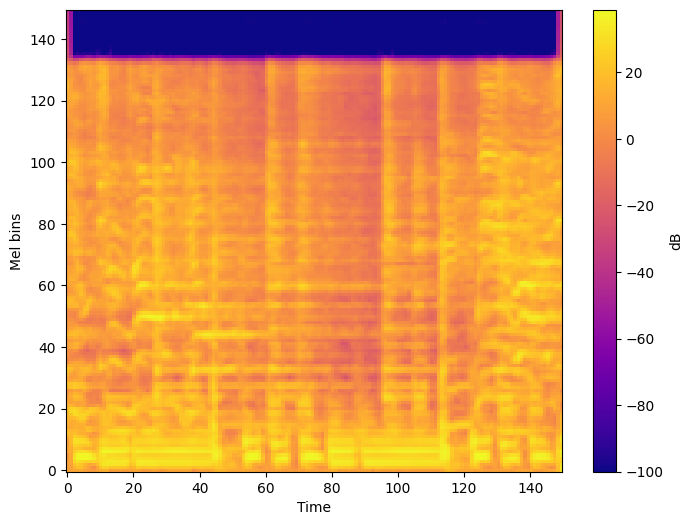

In [87]:
import matplotlib.pyplot as plt

spec = X_train[0]  # shape: (1, H, W)

plt.figure(figsize=(8, 6))

plt.imshow(
    spec.squeeze(0),
    aspect='auto',
    origin='lower',
    cmap='plasma'
)

plt.colorbar(label='dB')

plt.xlabel("Time")
plt.ylabel("Mel bins")

plt.show()

In [ ]:
# Save tensors for train / val / test splits

save_dir = Path('./data/saved_torch_not_normed_overlap')
save_dir.mkdir(parents=True, exist_ok=True)

torch.save({'X': X_train, 'y': y_train}, save_dir / 'train_tensors.pt')
torch.save({'X': X_val, 'y': y_val}, save_dir / 'val_tensors.pt')
torch.save({'X': X_test, 'y': y_test}, save_dir / 'test_tensors.pt')

print(f'Saved train tensors to {save_dir / "train_tensors.pt"}')
print(f'Saved val tensors to {save_dir / "val_tensors.pt"}')
print(f'Saved test tensors to {save_dir / "test_tensors.pt"}')

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

image_size = 150

#### 1.5 Loading data

In [95]:
# Load tensors before model training

load_dir = Path('./data/saved_torch_overlap')

train_data = torch.load(load_dir / 'train_tensors.pt', map_location='cpu')
val_data = torch.load(load_dir / 'val_tensors.pt', map_location='cpu')
test_data = torch.load(load_dir / 'test_tensors.pt', map_location='cpu')

X_train, y_train = train_data['X'], train_data['y']
X_val, y_val = val_data['X'], val_data['y']
X_test, y_test = test_data['X'], test_data['y']

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

torch.Size([9791, 1, 150, 150]) torch.Size([9791, 10])
torch.Size([1400, 1, 150, 150]) torch.Size([1400, 10])
torch.Size([2800, 1, 150, 150]) torch.Size([2800, 10])


#### 2. Model training
Don't try without GPU, since it'll run for hours in that case

Params below provide current optimal result

In [96]:
lr = 1e-4
weight_decay=2e-4
batch_size = 32
epoch_n = 50
num_classes = 10
channels = (16, 32, 64, 128)
dropout=0.33
image_size = 150

model = SciKitCNN(channels=channels,num_classes=num_classes,epoch_n=epoch_n, weight_decay=weight_decay, patience_threshold=8,
				batch_size=batch_size,lr=lr, dropout=dropout, label_smoothing=0.05, X_val=X_val, y_val=y_val)

In [97]:
model.fit(X_train, y_train)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50                    Loss: 1.4317 Val: 0.6280:   2%|▏         | 1/50 [00:10<08:29, 10.39s/it]

[0.0001]


Epoch 2/50                    Loss: 0.9396 Val: 0.7469:   4%|▍         | 2/50 [00:20<08:19, 10.41s/it]

[0.0001]


Epoch 3/50                    Loss: 0.7323 Val: 0.7732:   6%|▌         | 3/50 [00:31<08:08, 10.40s/it]

[0.0001]


Epoch 4/50                    Loss: 0.6052 Val: 0.7529:   8%|▊         | 4/50 [00:41<07:58, 10.41s/it]

[0.0001]


Epoch 5/50                    Loss: 0.5236 Val: 0.7647:  10%|█         | 5/50 [00:52<07:49, 10.44s/it]

[0.0001]


Epoch 6/50                    Loss: 0.4576 Val: 0.7558:  12%|█▏        | 6/50 [01:02<07:39, 10.44s/it]

[0.0001]


Epoch 7/50                    Loss: 0.3935 Val: 0.8058:  14%|█▍        | 7/50 [01:13<07:29, 10.44s/it]

[5e-05]


Epoch 8/50                    Loss: 0.3750 Val: 0.7987:  16%|█▌        | 8/50 [01:23<07:18, 10.44s/it]

[5e-05]


Epoch 9/50                    Loss: 0.3614 Val: 0.7759:  18%|█▊        | 9/50 [01:33<07:07, 10.42s/it]

[5e-05]


Epoch 10/50                    Loss: 0.3552 Val: 0.8029:  20%|██        | 10/50 [01:44<06:55, 10.39s/it]

[5e-05]


Epoch 11/50                    Loss: 0.3445 Val: 0.8007:  22%|██▏       | 11/50 [01:54<06:45, 10.39s/it]

[2.5e-05]


Epoch 12/50                    Loss: 0.3412 Val: 0.8014:  24%|██▍       | 12/50 [02:04<06:34, 10.38s/it]

[2.5e-05]


Epoch 13/50                    Loss: 0.3387 Val: 0.7983:  26%|██▌       | 13/50 [02:15<06:24, 10.40s/it]

[2.5e-05]


Epoch 14/50                    Loss: 0.3333 Val: 0.7982:  28%|██▊       | 14/50 [02:25<06:13, 10.38s/it]

[1.25e-05]


Epoch 15/50                    Loss: 0.3323 Val: 0.7993:  28%|██▊       | 14/50 [02:36<06:41, 11.15s/it]

[1.25e-05]

Early Stopped at 15 epoch


,X_val,tensor([[[[ -... -57.7574]]]])
,y_val,"tensor([[0., ... 1., 0., 0.]])"
,channels,"(16, ...)"
,num_classes,10
,dropout,0.33
,lr,0.0001
,label_smoothing,0.05
,weight_decay,0.0002
,patience_threshold,8
,epoch_n,50
,batch_size,32


In [98]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score

y_pred = model.predict(X_test)

y_test_np = y_test.argmax(dim=1).numpy()

print('Testing accuracy:', accuracy_score(y_test_np, y_pred))
print('Testing f1 score:', f1_score(y_test_np, y_pred, average="macro"))
print(classification_report(y_test_np,y_pred,target_names=genres))


Testing accuracy: 0.7757142857142857
Testing f1 score: 0.7745518363584692
              precision    recall  f1-score   support

       blues       0.85      0.83      0.84       280
   classical       0.83      0.95      0.88       280
     country       0.71      0.79      0.75       280
       disco       0.78      0.66      0.72       280
     hip-hop       0.95      0.82      0.88       280
        jazz       0.77      0.86      0.81       280
       metal       0.87      0.88      0.88       280
         pop       0.63      0.72      0.67       280
      reggae       0.77      0.69      0.73       280
        rock       0.63      0.56      0.59       280

    accuracy                           0.78      2800
   macro avg       0.78      0.78      0.77      2800
weighted avg       0.78      0.78      0.77      2800



In [ ]:
filename = Path("./ml/models/torch_model.pt")
model.save_model(filename)

Есть finetuning классификатора

In [ ]:
model.fine_tune(X_val, y_val, lr=1e-6, epochs=4, freeze_features=True)

In [48]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score

y_pred = model.predict(X_test)

y_test_np = y_test.argmax(dim=1).numpy()

print('Testing accuracy:', accuracy_score(y_test_np, y_pred))
print('Testing f1 score:', f1_score(y_test_np, y_pred, average="macro"))
#print('Testing roc-auc score:',roc_auc_score(y_test_np, y_pred, average="macro", multi_class="ovr"))
print(classification_report(y_test_np,y_pred,target_names=genres))


Testing accuracy: 0.8246428571428571
Testing f1 score: 0.8240612026380505
              precision    recall  f1-score   support

       blues       0.92      0.93      0.93       280
   classical       0.86      0.98      0.91       280
     country       0.77      0.80      0.78       280
       disco       0.85      0.69      0.76       280
     hip-hop       0.91      0.82      0.86       280
        jazz       0.83      0.87      0.85       280
       metal       0.85      0.92      0.88       280
         pop       0.70      0.82      0.76       280
      reggae       0.96      0.77      0.86       280
        rock       0.65      0.64      0.65       280

    accuracy                           0.82      2800
   macro avg       0.83      0.82      0.82      2800
weighted avg       0.83      0.82      0.82      2800



Визуализация карты признаков

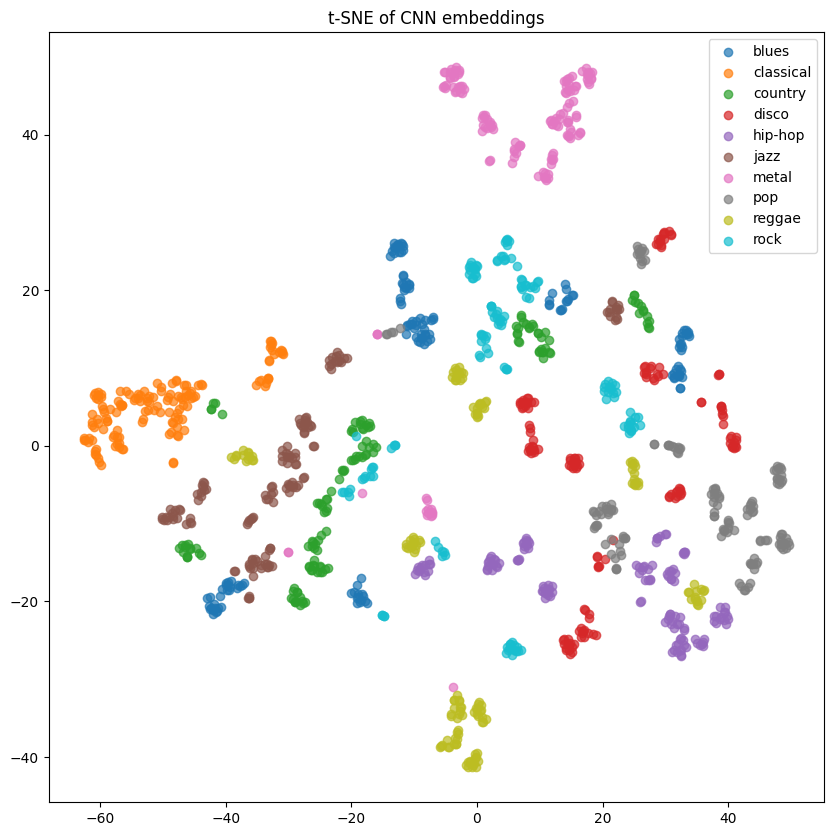

In [99]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features = model.extract_features(X_val)

y_labels = y_val.argmax(dim=1).numpy()

z = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
).fit_transform(features)

plt.figure(figsize=(10, 10))

for genre_id in np.unique(y_labels):
    mask = y_labels == genre_id

    plt.scatter(
        z[mask, 0],
        z[mask, 1],
        label=str(genre_id),
        alpha=0.7
    )

plt.legend(settings.GENRE_LABELS)
plt.title("t-SNE of CNN embeddings")
plt.show()

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

features_train = model.extract_features(X_train)
features_test = model.extract_features(X_test)

print("features_train shape:", features_train.shape)
print("y_train shape:", y_train.shape)

y_train_lbl = np.argmax(y_train, axis=1)
y_test_lbl = np.argmax(y_test, axis=1)

clf = LogisticRegression(max_iter=5000)
clf.fit(features_train, y_train_lbl)

pred = clf.predict(features_test)

print(classification_report(y_test_lbl, pred))

features_train shape: (9791, 128)
y_train shape: torch.Size([9791, 10])
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       280
           1       0.83      0.95      0.89       280
           2       0.72      0.71      0.72       280
           3       0.75      0.66      0.71       280
           4       0.89      0.82      0.85       280
           5       0.79      0.80      0.79       280
           6       0.86      0.85      0.85       280
           7       0.59      0.81      0.68       280
           8       0.88      0.75      0.81       280
           9       0.60      0.50      0.54       280

    accuracy                           0.77      2800
   macro avg       0.77      0.77      0.77      2800
weighted avg       0.77      0.77      0.77      2800



#### 3. Manual Testing

Ручное тестирование на логичность результата на избранных примерах вне основного набора данных:
- Graze The Roof (Jazz Remix) by Ruscel Torres
- Reach Out To The Truth -First Battle- by Atlus Sound Team
- String Theocracy (instrumental) and String Theocracy by Mili
- Metal (Limbus Company OST - Canto IX Boss 7 Battle Theme) by Studio EIM
- Disintigration and Lovecats by The Cure

In [60]:
filename = Path("./ml/models/deploy_model.pt")

model = SciKitCNN()
model.load_model(filename)

In [61]:
from ml.utils.utils import preprocess_audio_torch

In [62]:
audio_path = Path("./ml/audio_samples/Jazz.mp3")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'jazz', 'score': 0.5411242842674255},
 {'label': 'classical', 'score': 0.13724568486213684},
 {'label': 'blues', 'score': 0.0916479155421257},
 {'label': 'hip-hop', 'score': 0.058607134968042374},
 {'label': 'rock', 'score': 0.05179918557405472},
 {'label': 'reggae', 'score': 0.03822487220168114},
 {'label': 'disco', 'score': 0.03349298611283302},
 {'label': 'metal', 'score': 0.017092902213335037},
 {'label': 'pop', 'score': 0.01671474799513817},
 {'label': 'country', 'score': 0.014050127007067204}]

In [63]:
audio_path = Path("./ml/audio_samples/Reach Out To The Truth.flac")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'metal', 'score': 0.6280579566955566},
 {'label': 'classical', 'score': 0.0977373793721199},
 {'label': 'hip-hop', 'score': 0.08809369802474976},
 {'label': 'jazz', 'score': 0.06388578563928604},
 {'label': 'rock', 'score': 0.026366541162133217},
 {'label': 'pop', 'score': 0.024596385657787323},
 {'label': 'disco', 'score': 0.019888905808329582},
 {'label': 'country', 'score': 0.019757013767957687},
 {'label': 'reggae', 'score': 0.01803118735551834},
 {'label': 'blues', 'score': 0.013585138134658337}]

In [64]:
audio_path = Path("./ml/audio_samples/String Theocracy (inst).mp3")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'jazz', 'score': 0.2608013153076172},
 {'label': 'classical', 'score': 0.143289715051651},
 {'label': 'metal', 'score': 0.13888564705848694},
 {'label': 'country', 'score': 0.13229061663150787},
 {'label': 'pop', 'score': 0.07658801227807999},
 {'label': 'rock', 'score': 0.07037913799285889},
 {'label': 'hip-hop', 'score': 0.062029361724853516},
 {'label': 'disco', 'score': 0.047467172145843506},
 {'label': 'reggae', 'score': 0.04002547264099121},
 {'label': 'blues', 'score': 0.02824345789849758}]

In [65]:
audio_path = Path("./ml/audio_samples/ST.mp3")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'jazz', 'score': 0.2159862369298935},
 {'label': 'metal', 'score': 0.17281858623027802},
 {'label': 'country', 'score': 0.1300940364599228},
 {'label': 'classical', 'score': 0.12724824249744415},
 {'label': 'rock', 'score': 0.09545934200286865},
 {'label': 'hip-hop', 'score': 0.07613679766654968},
 {'label': 'pop', 'score': 0.07308071851730347},
 {'label': 'blues', 'score': 0.04344157502055168},
 {'label': 'reggae', 'score': 0.03376666456460953},
 {'label': 'disco', 'score': 0.03196776658296585}]

In [66]:
audio_path = Path("./ml/audio_samples/Metal.mp3")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'metal', 'score': 0.7483096718788147},
 {'label': 'classical', 'score': 0.09980684518814087},
 {'label': 'rock', 'score': 0.04276903718709946},
 {'label': 'reggae', 'score': 0.021947279572486877},
 {'label': 'jazz', 'score': 0.018628181889653206},
 {'label': 'hip-hop', 'score': 0.01790476404130459},
 {'label': 'pop', 'score': 0.015419469214975834},
 {'label': 'disco', 'score': 0.014802508987486362},
 {'label': 'country', 'score': 0.011307353153824806},
 {'label': 'blues', 'score': 0.009104852564632893}]

In [67]:
audio_path = Path("./ml/audio_samples/disintegration.mp3")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'rock', 'score': 0.3418402075767517},
 {'label': 'classical', 'score': 0.3116878271102905},
 {'label': 'metal', 'score': 0.18597030639648438},
 {'label': 'jazz', 'score': 0.04726459085941315},
 {'label': 'pop', 'score': 0.029235990718007088},
 {'label': 'hip-hop', 'score': 0.023999350145459175},
 {'label': 'disco', 'score': 0.01605895534157753},
 {'label': 'country', 'score': 0.015879888087511063},
 {'label': 'reggae', 'score': 0.014381668530404568},
 {'label': 'blues', 'score': 0.013681204989552498}]

In [68]:
audio_path = Path("./ml/audio_samples/lovecats.mp3")
X_for_inference = preprocess_audio_torch(audio_path)

model.predict_genre(X_for_inference)

[{'label': 'jazz', 'score': 0.21207356452941895},
 {'label': 'classical', 'score': 0.17916573584079742},
 {'label': 'hip-hop', 'score': 0.16197019815444946},
 {'label': 'rock', 'score': 0.14181561768054962},
 {'label': 'blues', 'score': 0.06273765116930008},
 {'label': 'disco', 'score': 0.05499478057026863},
 {'label': 'metal', 'score': 0.05431992560625076},
 {'label': 'pop', 'score': 0.04700567573308945},
 {'label': 'reggae', 'score': 0.0461127832531929},
 {'label': 'country', 'score': 0.0398041196167469}]

#### 4. Optuna optimization
To change param bounds for optimization go to .ml.utils.param_search.Objective

In [ ]:
from ml.utils.param_search import ModelOptimization

model_list = ["CNN"]

OS = ModelOptimization(model_list)
OS.fit(X_train, y_train, X_val, y_val, n_trials=15, n_startup_trials=5)